# Unsupervised ML Phase Detection for MEOP Polarization Data

## Objective
Automatically detect the four phases of MEOP polarization time-series data using **unsupervised machine learning** — no hand-tuned thresholds or derivative heuristics.

### The Four Phases
| Phase | Behavior | Physics |
|-------|----------|---------|
| 1. **Initial Constant** | Signal flat near baseline | He-3 at thermal equilibrium |
| 2. **Buildup** | Exponential rise | Optical pumping creates nuclear polarization |
| 3. **Plateau** | Signal flat at maximum | Pumping ↔ relaxation equilibrium |
| 4. **Decay** | Exponential fall | Relaxation after pump-off |

### ML Methods Used
1. **Feature Engineering**: Rolling statistics, derivatives, curvature → per-point feature vectors
2. **Gaussian Mixture Model (GMM)**: Soft clustering of feature space into 4 behavioral regimes
3. **Hidden Markov Model (HMM)**: Temporal sequence model that enforces smooth state transitions
4. **PELT Change-Point Detection**: Structural break detection in the signal
5. **Physics-Aware Labeling**: Auto-assign cluster IDs → physical phase labels using signal context
6. **Comparison**: ML ranges vs. derivative-based ranges from `power_dependence_analysis.ipynb`

In [1]:
# ============================================================================
# Cell 1: Install & Import Dependencies
# ============================================================================
import subprocess, sys

# Install ML packages if not present
required = ['scikit-learn', 'hmmlearn', 'ruptures']
for pkg in required:
    try:
        __import__(pkg.replace('-', '_').replace('scikit_learn', 'sklearn'))
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from hmmlearn import hmm
import ruptures

print("All imports successful ✓")
print(f"  numpy {np.__version__}")
print(f"  scikit-learn: {__import__('sklearn').__version__}")
print(f"  hmmlearn: {__import__('hmmlearn').__version__}")
print(f"  ruptures: {__import__('ruptures').__version__}")

Installing hmmlearn...
Installing ruptures...
All imports successful ✓
  numpy 2.3.5
  scikit-learn: 1.7.2
  hmmlearn: 0.3.3
  ruptures: 1.1.9


## 1. Data Loading & Preprocessing

Load Excel files, convert times, apply smoothing — identical pipeline to the main analysis notebook so results are directly comparable.

In [2]:
# ============================================================================
# Cell 2: Data Loading & Preprocessing Functions
# ============================================================================

DATA_DIR = "/Users/snip/Documents/MEOP/Power Dependence Tests"
OUTPUT_DIR = "/Users/snip/Documents/MEOP/ml_phase_plots"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

def time_to_seconds(time_str):
    """Convert MM:SS or HH:MM:SS string to seconds."""
    parts = str(time_str).split(':')
    if len(parts) == 2:
        return int(parts[0]) * 60 + float(parts[1])
    elif len(parts) == 3:
        return int(parts[0]) * 3600 + int(parts[1]) * 60 + float(parts[2])
    return float(time_str)

def load_and_preprocess(file_path):
    """
    Load an Excel file and return a clean DataFrame with columns:
    time, polarization, smoothed, derivative
    
    Handles time rollover detection (59:59 → 00:00) and applies
    Savitzky-Golay smoothing identical to the main analysis notebook.
    """
    df = pd.read_excel(str(file_path))
    df.drop(columns=["Time - Voltage (Formula Result)",
                      "Polarization (%) - Voltage (Formula Result)"], inplace=True)
    df.rename(columns={
        "Time - Voltage (Formula Result).1": "time",
        "Polarization (%) - Voltage (Formula Result).1": "polarization"
    }, inplace=True)
    
    # Time conversion with rollover detection
    t_sec = df["time"].apply(time_to_seconds).values
    corrected = [t_sec[0]]
    cum_offset = 0
    for i in range(1, len(t_sec)):
        if t_sec[i] < t_sec[i-1] - 10:
            cum_offset += 3600
        corrected.append(t_sec[i] + cum_offset)
    df["time"] = corrected
    df["time"] = df["time"] - df["time"].min()
    
    # Smoothing (same parameters as main notebook)
    df["smoothed"] = savgol_filter(df["polarization"], 30, 3)
    df["derivative"] = np.gradient(df["smoothed"])
    
    return df

# Load all files
excel_files = sorted(Path(DATA_DIR).glob("*.xlsx"))
print(f"Found {len(excel_files)} Excel files\n")

# Demo with first few files
for f in excel_files[:5]:
    print(f"  {f.stem}")
print("  ...")

# Load a single file for development
demo_file = excel_files[1]  # 3W_C9_datagrab1.xlsx (same as main notebook)
df = load_and_preprocess(demo_file)
filename = demo_file.stem
print(f"\nLoaded: {filename}")
print(f"  Points: {len(df)}")
print(f"  Time range: [{df['time'].min():.1f}, {df['time'].max():.1f}] s")
print(f"  Polarization range: [{df['polarization'].min():.1f}, {df['polarization'].max():.1f}] %")

Found 37 Excel files

  3W_C8_datagrab1
  3W_C8_datagrab2
  3W_C8_datagrab3
  3W_C9_datagrab1
  3W_C9_datagrab2
  ...

Loaded: 3W_C8_datagrab2
  Points: 884
  Time range: [0.0, 928.2] s
  Polarization range: [2.9, 62.3] %


## 2. Feature Engineering

Each time point gets a **feature vector** describing its local behavior. The ML models cluster these vectors — points with similar features end up in the same phase.

### Features per point:
| Feature | Description | Why it helps |
|---------|-------------|--------------|
| `pol_norm` | Normalized polarization [0,1] | Separates low (const) from high (plateau) |
| `deriv_norm` | Normalized 1st derivative | Positive → buildup, negative → decay, zero → constant/plateau |
| `deriv2_norm` | Normalized 2nd derivative (curvature) | Inflection points at phase transitions |
| `roll_mean` | Rolling mean of polarization (window=30) | Smoothed signal level |
| `roll_std` | Rolling std of polarization (window=30) | High during transitions, low during constant phases |
| `deriv_roll_mean` | Rolling mean of derivative (window=20) | Sustained trend direction |
| `abs_deriv` | |derivative| | Magnitude of change regardless of direction |
| `time_norm` | Normalized time [0,1] | Weak prior: constants at start/end, transitions in middle |

Feature matrix shape: (884, 8)
Features: ['pol_norm', 'deriv_norm', 'deriv2_norm', 'roll_mean_norm', 'roll_std_norm', 'deriv_roll_norm', 'abs_deriv', 'time_norm']



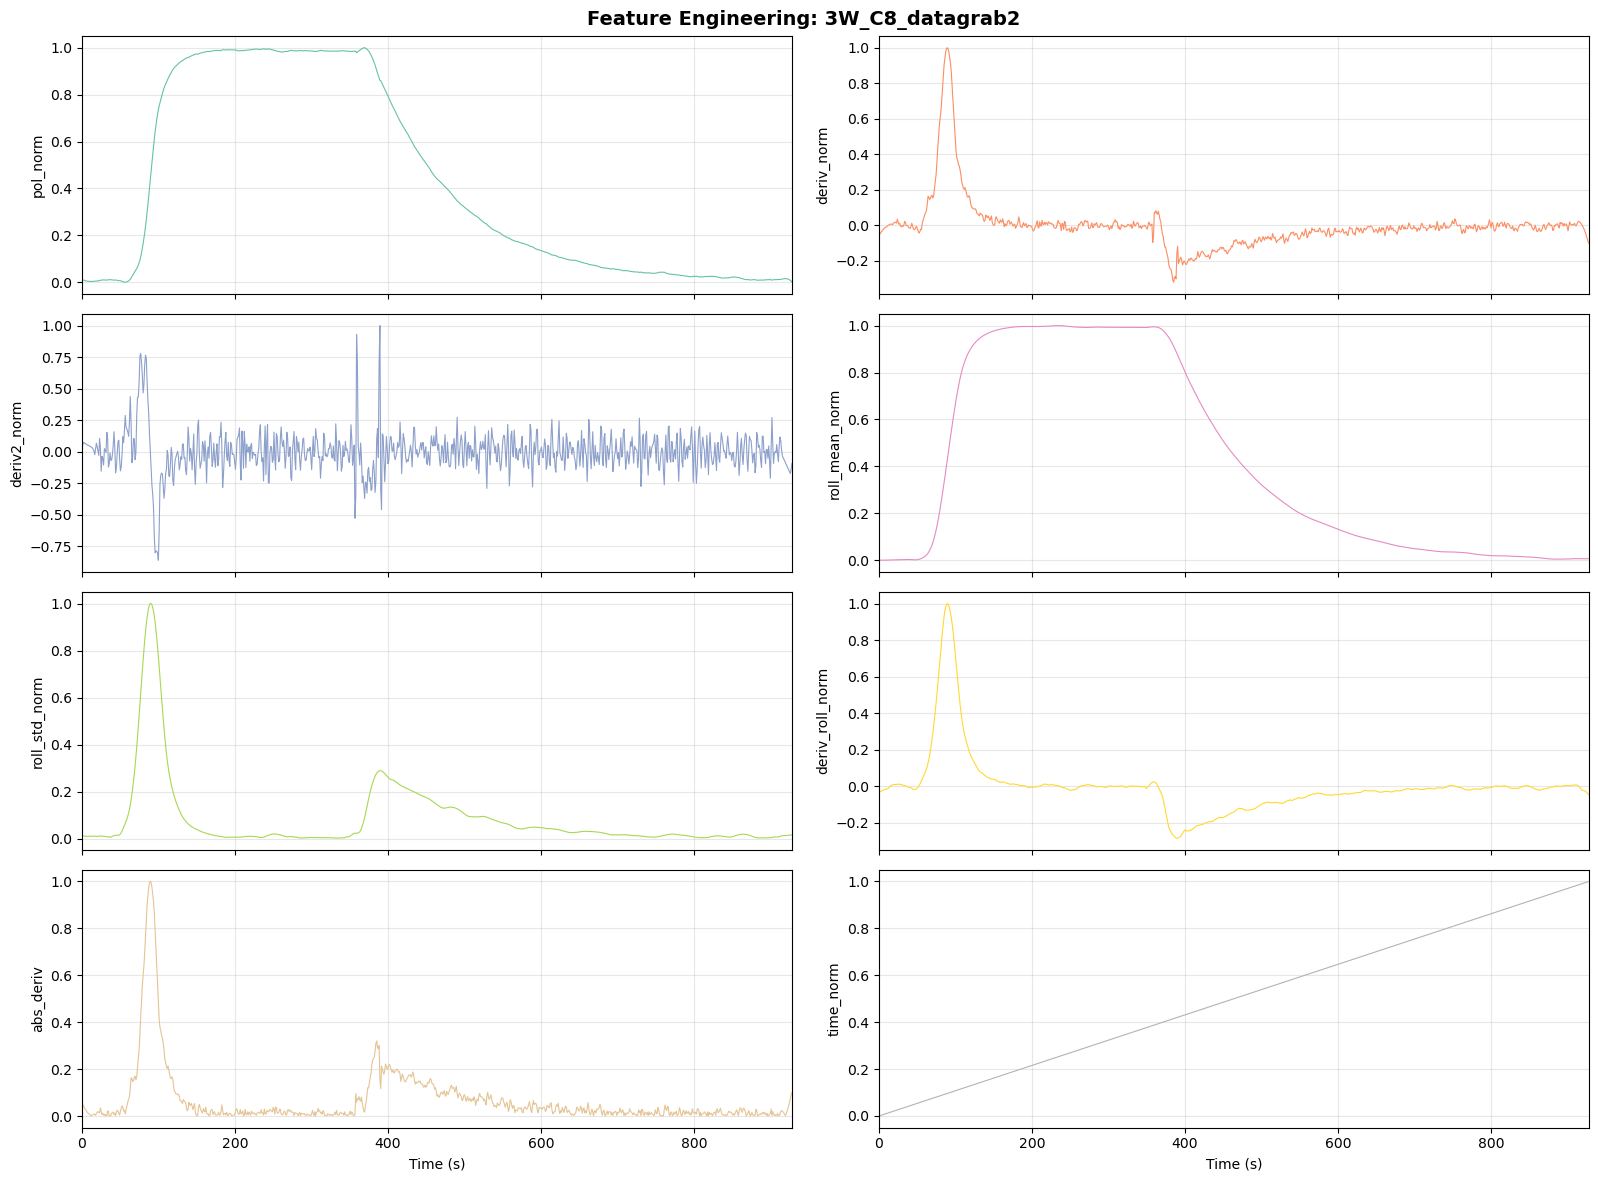

In [3]:
# ============================================================================
# Cell 3: Feature Engineering
# ============================================================================

def extract_features(df):
    """
    Extract per-point feature vectors from preprocessed polarization data.
    
    Returns:
        features: np.ndarray of shape (N, n_features)
        feature_names: list of feature name strings
    """
    time = df["time"].values
    pol = df["smoothed"].values
    deriv = df["derivative"].values
    
    # --- Normalized signal features ---
    pol_range = pol.max() - pol.min()
    pol_norm = (pol - pol.min()) / (pol_range + 1e-10)
    
    # --- Derivative features ---
    deriv_scale = max(abs(deriv.max()), abs(deriv.min())) + 1e-10
    deriv_norm = deriv / deriv_scale
    
    # Second derivative (curvature)
    deriv2 = np.gradient(deriv)
    deriv2_scale = max(abs(deriv2.max()), abs(deriv2.min())) + 1e-10
    deriv2_norm = deriv2 / deriv2_scale
    
    # Absolute derivative (change magnitude)
    abs_deriv = np.abs(deriv_norm)
    
    # --- Rolling statistics ---
    ser_pol = pd.Series(pol)
    ser_deriv = pd.Series(deriv)
    
    roll_mean = ser_pol.rolling(window=30, center=True, min_periods=1).mean().values
    roll_mean_norm = (roll_mean - roll_mean.min()) / (roll_mean.max() - roll_mean.min() + 1e-10)
    
    roll_std = ser_pol.rolling(window=30, center=True, min_periods=1).std().fillna(0).values
    roll_std_norm = roll_std / (roll_std.max() + 1e-10)
    
    deriv_roll_mean = ser_deriv.rolling(window=20, center=True, min_periods=1).mean().values
    deriv_roll_norm = deriv_roll_mean / (max(abs(deriv_roll_mean.max()), abs(deriv_roll_mean.min())) + 1e-10)
    
    # --- Time feature (weak positional prior) ---
    time_norm = (time - time.min()) / (time.max() - time.min() + 1e-10)
    
    # Stack into feature matrix
    features = np.column_stack([
        pol_norm,           # 0: signal level
        deriv_norm,         # 1: rate of change direction
        deriv2_norm,        # 2: curvature
        roll_mean_norm,     # 3: smoothed level
        roll_std_norm,      # 4: local variability
        deriv_roll_norm,    # 5: sustained trend
        abs_deriv,          # 6: change magnitude
        time_norm,          # 7: position in sequence
    ])
    
    feature_names = [
        'pol_norm', 'deriv_norm', 'deriv2_norm', 'roll_mean_norm',
        'roll_std_norm', 'deriv_roll_norm', 'abs_deriv', 'time_norm'
    ]
    
    return features, feature_names

# Extract features for demo file
features, feature_names = extract_features(df)
print(f"Feature matrix shape: {features.shape}")
print(f"Features: {feature_names}\n")

# Visualize features
fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)
fig.suptitle(f"Feature Engineering: {filename}", fontsize=14, fontweight='bold')
time = df["time"].values

for i, (ax, name) in enumerate(zip(axes.flat, feature_names)):
    ax.plot(time, features[:, i], linewidth=0.8, color=plt.cm.Set2(i))
    ax.set_ylabel(name, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(time[0], time[-1])

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## 3. Method 1 — Gaussian Mixture Model (GMM)

**Idea**: Each phase has a characteristic "fingerprint" in feature space. A GMM fits 4 Gaussian blobs to the feature vectors, assigning each time point a soft probability of belonging to each cluster.

**Advantages**: 
- Soft assignments give confidence levels at boundaries
- No assumption about temporal ordering (purely feature-based)

**Limitation**: GMM treats each point independently — it doesn't know about temporal continuity, so labels can flicker near transitions. We fix this with post-processing.

In [4]:
# ============================================================================
# Cell 4: Gaussian Mixture Model (GMM) Phase Detection
# ============================================================================

def gmm_phase_detection(df, features, n_phases=4, random_state=42):
    """
    Cluster time points into phases using Gaussian Mixture Model.
    
    Steps:
    1. Standardize features
    2. Fit GMM with n_phases components
    3. Get hard labels + soft probabilities
    4. Median-filter labels to remove flickering
    5. Physics-aware relabeling (assign cluster IDs to physical phases)
    
    Returns:
        labels: np.ndarray of phase labels (0=IC, 1=BU, 2=PL, 3=DC)
        probs: np.ndarray of shape (N, 4) — posterior probabilities
        gmm: fitted GaussianMixture object
    """
    time = df["time"].values
    pol = df["smoothed"].values
    
    # Standardize features
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    
    # Fit GMM
    gmm = GaussianMixture(
        n_components=n_phases,
        covariance_type='full',
        n_init=10,
        max_iter=500,
        random_state=random_state
    )
    gmm.fit(X)
    
    raw_labels = gmm.predict(X)
    probs = gmm.predict_proba(X)
    
    # --- Temporal smoothing: median filter to remove label flickering ---
    from scipy.ndimage import median_filter
    smooth_labels = median_filter(raw_labels, size=25)
    
    # --- Physics-aware relabeling ---
    # The cluster IDs from GMM are arbitrary (0-3). We need to map them to
    # physical phases based on WHEN and WHERE each cluster appears.
    #
    # Strategy: For each cluster, compute its median time and median polarization.
    # - Initial Constant: earliest median time, low polarization
    # - Buildup: positive mean derivative, rising signal
    # - Plateau: high polarization, near-zero derivative, middle-to-late time
    # - Decay: late time, negative mean derivative
    
    labels = relabel_phases(smooth_labels, df)
    
    return labels, probs, gmm


def relabel_phases(raw_labels, df):
    """
    Map arbitrary cluster IDs to physical phase labels:
    0 = Initial Constant, 1 = Buildup, 2 = Plateau, 3 = Decay
    
    Uses a scoring system based on physics context:
    - Median time position
    - Mean signal level  
    - Mean derivative (positive = buildup, negative = decay, ~zero = constant)
    """
    time = df["time"].values
    pol = df["smoothed"].values
    deriv = df["derivative"].values
    
    unique_labels = np.unique(raw_labels)
    n_clusters = len(unique_labels)
    
    # Compute cluster statistics
    cluster_stats = {}
    for c in unique_labels:
        mask = raw_labels == c
        cluster_stats[c] = {
            'median_time': np.median(time[mask]),
            'mean_pol': np.mean(pol[mask]),
            'mean_deriv': np.mean(deriv[mask]),
            'median_pol': np.median(pol[mask]),
            'count': np.sum(mask),
            'time_start': time[mask][0] if np.any(mask) else np.inf,
            'time_end': time[mask][-1] if np.any(mask) else -np.inf,
        }
    
    # Scoring: assign each cluster to the phase it best matches
    # Phase 0 (IC):  earliest time, low polarization, ~zero derivative
    # Phase 1 (BU):  positive derivative, rising signal
    # Phase 2 (PL):  high polarization, ~zero derivative, middle time
    # Phase 3 (DC):  negative derivative, late time, falling signal
    
    label_map = {}
    used_clusters = set()
    
    # 1. Buildup: highest mean derivative (most positive)
    bu_cluster = max(unique_labels, key=lambda c: cluster_stats[c]['mean_deriv'])
    label_map[bu_cluster] = 1  # Buildup
    used_clusters.add(bu_cluster)
    
    # 2. Decay: lowest mean derivative (most negative)
    remaining = [c for c in unique_labels if c not in used_clusters]
    dc_cluster = min(remaining, key=lambda c: cluster_stats[c]['mean_deriv'])
    label_map[dc_cluster] = 3  # Decay
    used_clusters.add(dc_cluster)
    
    # 3. Initial Constant vs Plateau: both have ~zero derivative
    #    IC has lower polarization, PL has higher polarization
    remaining = [c for c in unique_labels if c not in used_clusters]
    if len(remaining) >= 2:
        # Sort by mean polarization: lower = IC, higher = PL
        remaining_sorted = sorted(remaining, key=lambda c: cluster_stats[c]['mean_pol'])
        label_map[remaining_sorted[0]] = 0   # Initial Constant (low pol)
        label_map[remaining_sorted[1]] = 2   # Plateau (high pol)
    elif len(remaining) == 1:
        # Only one left — decide based on time
        c = remaining[0]
        if cluster_stats[c]['median_time'] < cluster_stats[bu_cluster]['median_time']:
            label_map[c] = 0  # IC
        else:
            label_map[c] = 2  # PL
    
    # Apply mapping
    labels = np.array([label_map.get(l, l) for l in raw_labels])
    
    return labels


# Run GMM
gmm_labels, gmm_probs, gmm_model = gmm_phase_detection(df, features)

# Summary
phase_names = {0: 'Initial Constant', 1: 'Buildup', 2: 'Plateau', 3: 'Decay'}
phase_colors = {0: '#3498db', 1: '#0f803e', 2: '#f39c12', 3: '#e74c3c'}

print(f"GMM Phase Detection: {filename}")
print(f"  BIC: {gmm_model.bic(StandardScaler().fit_transform(features)):.1f}")
print(f"  AIC: {gmm_model.aic(StandardScaler().fit_transform(features)):.1f}")
print()
for phase_id, name in phase_names.items():
    mask = gmm_labels == phase_id
    if np.any(mask):
        t_start = df["time"].values[mask].min()
        t_end = df["time"].values[mask].max()
        print(f"  Phase {phase_id} ({name:>18s}): {np.sum(mask):4d} points, t = [{t_start:.1f}, {t_end:.1f}] s")

GMM Phase Detection: 3W_C8_datagrab2
  BIC: -14509.6
  AIC: -15366.0

  Phase 0 (  Initial Constant):  125 points, t = [0.0, 928.2] s
  Phase 1 (           Buildup):   79 points, t = [56.5, 138.7] s
  Phase 2 (           Plateau):  219 points, t = [139.7, 368.4] s
  Phase 3 (             Decay):  461 points, t = [369.5, 883.2] s


## 4. Method 2 — Hidden Markov Model (HMM)

**Idea**: An HMM treats the time series as a sequence of hidden states (the 4 phases) that emit observable features. Unlike GMM, an HMM **models temporal transitions** — it knows that "Initial Constant → Buildup" is likely but "Decay → Buildup" is not.

**Advantages**:
- Enforces temporal coherence (no flickering labels)
- Transition matrix reveals the probability of switching between phases
- Most natural model for sequential phase data

**Key addition**: We use the Viterbi algorithm to find the single most likely state sequence.

In [6]:
# ============================================================================
# Cell 5: Hidden Markov Model (HMM) Phase Detection
# ============================================================================

def hmm_phase_detection(df, features, n_phases=4, random_state=42):
    """
    Detect phases using a Gaussian HMM with temporal transition modeling.
    
    The HMM is initialized with a transition matrix that encodes our prior
    knowledge about phase ordering: IC → BU → PL → DC (forward-only is most
    likely, but backward transitions are allowed with low probability).
    
    Returns:
        labels: np.ndarray of phase labels (0=IC, 1=BU, 2=PL, 3=DC)
        model: fitted GaussianHMM object
        log_likelihood: model log-likelihood
    """
    time = df["time"].values
    pol = df["smoothed"].values
    
    # Standardize features
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    
    # Initialize HMM with physics-informed transition matrix
    # Use 'diag' covariance for numerical stability (full can become singular)
    # Add small epsilon to zero transition probs to avoid degenerate states
    eps = 1e-4
    model = hmm.GaussianHMM(
        n_components=n_phases,
        covariance_type='diag',
        n_iter=200,
        random_state=random_state,
        init_params='mc',  # Initialize means and covariances from data
        params='stmc',     # Train all parameters
    )
    
    # Start probability: very likely to start in state 0
    model.startprob_ = np.array([0.85, 0.10, 0.03, 0.02])
    
    # Transition matrix: favor staying in current state + forward transitions
    # Small eps in zeros to prevent numerical issues during EM
    model.transmat_ = np.array([
        [0.95,  0.05,  eps,   eps ],   # IC → IC (stay) or IC → BU
        [eps,   0.95,  0.05,  eps ],   # BU → BU (stay) or BU → PL
        [eps,   eps,   0.95,  0.05],   # PL → PL (stay) or PL → DC
        [eps,   eps,   eps,   1.0 ],   # DC → DC (stay, absorbing)
    ])
    # Normalize rows to sum to 1
    model.transmat_ = model.transmat_ / model.transmat_.sum(axis=1, keepdims=True)
    
    # Fit the model (with retry on failure using simpler covariance)
    try:
        model.fit(X)
    except (ValueError, np.linalg.LinAlgError):
        # Fallback: use spherical covariance if diag fails
        model = hmm.GaussianHMM(
            n_components=n_phases, covariance_type='spherical',
            n_iter=200, random_state=random_state)
        model.fit(X)
    
    # Decode: Viterbi algorithm for most likely state sequence
    log_prob, raw_labels = model.decode(X, algorithm='viterbi')
    
    # Physics-aware relabeling (same approach as GMM)
    labels = relabel_phases(raw_labels, df)
    
    return labels, model, log_prob


# Run HMM
hmm_labels, hmm_model, hmm_logprob = hmm_phase_detection(df, features)

print(f"HMM Phase Detection: {filename}")
print(f"  Log-likelihood: {hmm_logprob:.1f}")
print(f"\n  Learned transition matrix:")
trans = hmm_model.transmat_
for i in range(4):
    row = " ".join([f"{trans[i,j]:.3f}" for j in range(4)])
    print(f"    State {i}: [{row}]")
print()
for phase_id, name in phase_names.items():
    mask = hmm_labels == phase_id
    if np.any(mask):
        t_start = df["time"].values[mask].min()
        t_end = df["time"].values[mask].max()
        print(f"  Phase {phase_id} ({name:>18s}): {np.sum(mask):4d} points, t = [{t_start:.1f}, {t_end:.1f}] s")

HMM Phase Detection: 3W_C8_datagrab2
  Log-likelihood: 863.1

  Learned transition matrix:
    State 0: [0.995 0.000 0.000 0.005]
    State 1: [0.000 0.998 0.002 0.000]
    State 2: [0.012 0.000 0.988 0.000]
    State 3: [0.000 0.005 0.000 0.995]

  Phase 0 (  Initial Constant):  403 points, t = [0.0, 928.2] s
  Phase 1 (           Buildup):   86 points, t = [57.5, 147.1] s
  Phase 2 (           Plateau):  210 points, t = [148.1, 367.4] s
  Phase 3 (             Decay):  185 points, t = [368.4, 561.8] s


## 5. Method 3 — PELT Change-Point Detection

**Idea**: Instead of clustering points into phases, PELT (Pruned Exact Linear Time) directly finds the **time indices where the signal behavior changes**. It detects 3 change-points that divide the time series into 4 segments.

**Advantages**:
- Directly gives boundary locations (no post-processing needed)
- Statistically principled: minimizes a penalized cost function
- Fast: O(n) complexity

**Model**: We use `rbf` kernel cost (non-parametric) which can detect changes in mean, variance, and distribution shape simultaneously.

In [7]:
# ============================================================================
# Cell 6: PELT Change-Point Detection
# ============================================================================

def pelt_phase_detection(df, features, n_breakpoints=3):
    """
    Detect phase boundaries using PELT (Pruned Exact Linear Time) algorithm.
    
    Finds exactly n_breakpoints change-points that divide the signal into
    n_breakpoints + 1 segments = 4 phases.
    
    Uses multiple signal representations and picks the best one via
    a combined cost approach.
    
    Returns:
        labels: np.ndarray of phase labels (0=IC, 1=BU, 2=PL, 3=DC)
        breakpoints: list of 3 breakpoint indices
        breakpoint_times: list of 3 breakpoint times in seconds
    """
    time = df["time"].values
    pol = df["smoothed"].values
    deriv = df["derivative"].values
    
    # Use smoothed polarization + derivative as the signal for change-point detection
    # This captures both level changes and rate changes
    signal = np.column_stack([
        (pol - pol.min()) / (pol.max() - pol.min() + 1e-10),
        deriv / (max(abs(deriv.max()), abs(deriv.min())) + 1e-10),
    ])
    
    # --- Method A: PELT with RBF kernel ---
    # Penalty parameter controls sensitivity: higher = fewer breakpoints
    # We use Binseg (Binary Segmentation) with exact n_bkps for guaranteed 3 breaks
    algo_rbf = ruptures.Binseg(model="rbf", min_size=20).fit(signal)
    bkps_rbf = algo_rbf.predict(n_bkps=n_breakpoints)
    
    # --- Method B: PELT on polarization alone (detects level shifts) ---
    algo_l2 = ruptures.Binseg(model="l2", min_size=20).fit(pol.reshape(-1, 1))
    bkps_l2 = algo_l2.predict(n_bkps=n_breakpoints)
    
    # --- Method C: Bottom-up segmentation (complementary approach) ---
    algo_bu = ruptures.BottomUp(model="l2", min_size=20).fit(signal)
    bkps_bu = algo_bu.predict(n_bkps=n_breakpoints)
    
    # --- Ensemble: pick the breakpoints that best separate the 4 expected phases ---
    # Score each set of breakpoints by how well the resulting segments match
    # expected phase characteristics
    best_score = -np.inf
    best_bkps = bkps_rbf
    
    for bkps_candidate, method_name in [(bkps_rbf, 'RBF'), (bkps_l2, 'L2'), (bkps_bu, 'BottomUp')]:
        score = score_breakpoints(bkps_candidate, df)
        if score > best_score:
            best_score = score
            best_bkps = bkps_candidate
    
    # Convert breakpoint indices to labels
    breakpoints = sorted(best_bkps[:-1])  # Remove the last one (=len(signal))
    
    labels = np.zeros(len(time), dtype=int)
    for i, bp in enumerate(breakpoints):
        labels[bp:] = i + 1
    
    # Physics-aware relabeling
    labels = relabel_phases(labels, df)
    
    breakpoint_times = [time[min(bp, len(time)-1)] for bp in breakpoints]
    
    return labels, breakpoints, breakpoint_times


def score_breakpoints(bkps, df):
    """
    Score a set of breakpoints based on how well segments match expected phases.
    
    Good breakpoints should create:
    - Segment 1 (IC): low, flat signal
    - Segment 2 (BU): rising signal (positive derivative)
    - Segment 3 (PL): high, flat signal
    - Segment 4 (DC): falling signal (negative derivative)
    """
    pol = df["smoothed"].values
    deriv = df["derivative"].values
    
    bkps_sorted = sorted([b for b in bkps if b < len(pol)])
    if len(bkps_sorted) < 3:
        return -np.inf
    
    segments = []
    prev = 0
    for bp in bkps_sorted:
        segments.append((prev, bp))
        prev = bp
    segments.append((prev, len(pol)))
    
    if len(segments) != 4:
        return -np.inf
    
    score = 0.0
    
    # Segment 1 (IC): should have low std (flat) and low mean polarization
    s1 = pol[segments[0][0]:segments[0][1]]
    d1 = deriv[segments[0][0]:segments[0][1]]
    if len(s1) > 2:
        score += -np.std(s1) * 10   # Reward flatness
        score += -np.mean(s1)       # Reward low level
        score += -abs(np.mean(d1)) * 50  # Reward near-zero derivative
    
    # Segment 2 (BU): should have positive mean derivative (rising)
    d2 = deriv[segments[1][0]:segments[1][1]]
    if len(d2) > 2:
        score += np.mean(d2) * 100  # Reward positive derivative
    
    # Segment 3 (PL): should be flat and high
    s3 = pol[segments[2][0]:segments[2][1]]
    d3 = deriv[segments[2][0]:segments[2][1]]
    if len(s3) > 2:
        score += -np.std(s3) * 10   # Reward flatness
        score += np.mean(s3)        # Reward high level
        score += -abs(np.mean(d3)) * 50  # Reward near-zero derivative
    
    # Segment 4 (DC): should have negative mean derivative (falling)
    d4 = deriv[segments[3][0]:segments[3][1]]
    if len(d4) > 2:
        score += -np.mean(d4) * 100  # Reward negative derivative (more negative = better)
    
    return score


# Run PELT
pelt_labels, pelt_bkps, pelt_bkp_times = pelt_phase_detection(df, features)

print(f"PELT Change-Point Detection: {filename}")
print(f"  Breakpoints at indices: {pelt_bkps}")
print(f"  Breakpoints at times:   {[f'{t:.1f}s' for t in pelt_bkp_times]}")
print()
for phase_id, name in phase_names.items():
    mask = pelt_labels == phase_id
    if np.any(mask):
        t_start = df["time"].values[mask].min()
        t_end = df["time"].values[mask].max()
        print(f"  Phase {phase_id} ({name:>18s}): {np.sum(mask):4d} points, t = [{t_start:.1f}, {t_end:.1f}] s")

PELT Change-Point Detection: 3W_C8_datagrab2
  Breakpoints at indices: [85, 385, 450]
  Breakpoints at times:   ['90.4s', '405.3s', '473.6s']

  Phase 0 (  Initial Constant):  434 points, t = [473.6, 928.2] s
  Phase 1 (           Buildup):   85 points, t = [0.0, 89.3] s
  Phase 2 (           Plateau):  300 points, t = [90.4, 404.2] s
  Phase 3 (             Decay):   65 points, t = [405.3, 472.6] s


## 6. Ensemble: Combine All Methods

Each method has strengths:
- **GMM**: Best at separating signal levels (constant vs. exponential regions)
- **HMM**: Best temporal coherence (smooth state sequences)
- **PELT**: Best at locating exact transition points

We combine them with **majority voting** and confidence weighting to produce a final consensus segmentation.

In [8]:
# ============================================================================
# Cell 7: Ensemble Combination + Range Extraction
# ============================================================================

def ensemble_phase_detection(gmm_labels, hmm_labels, pelt_labels, df):
    """
    Combine three ML methods via majority voting + temporal smoothing.
    
    For each time point, the phase is the one that at least 2/3 methods agree on.
    Ties are broken by the HMM (since it has the best temporal model).
    
    Returns:
        labels: final consensus labels
    """
    from scipy.stats import mode
    from scipy.ndimage import median_filter
    
    n = len(gmm_labels)
    votes = np.stack([gmm_labels, hmm_labels, pelt_labels], axis=1)  # (N, 3)
    
    # Majority vote
    ensemble_labels = np.zeros(n, dtype=int)
    for i in range(n):
        vals, counts = np.unique(votes[i], return_counts=True)
        max_count = counts.max()
        winners = vals[counts == max_count]
        if len(winners) == 1:
            ensemble_labels[i] = winners[0]
        else:
            # Tie: use HMM label (best temporal model)
            ensemble_labels[i] = hmm_labels[i]
    
    # Final temporal smoothing
    ensemble_labels = median_filter(ensemble_labels, size=15)
    
    # Enforce monotonic phase ordering: IC(0) → BU(1) → PL(2) → DC(3)
    # If a point has a label lower than the maximum seen so far AND we're
    # well past that phase, force it forward.
    max_seen = 0
    for i in range(n):
        if ensemble_labels[i] >= max_seen:
            max_seen = ensemble_labels[i]
        elif max_seen - ensemble_labels[i] >= 2:
            # More than 1 phase backward — likely an error, snap forward
            ensemble_labels[i] = max_seen
    
    return ensemble_labels


def extract_ranges_from_labels(labels, df):
    """
    Convert per-point phase labels into fit ranges (t_min, t_max) for each phase.
    
    For each phase, finds the first and last time point assigned to that phase.
    Applies a small buffer at boundaries to avoid edge effects.
    
    Returns:
        dict with keys like 'initial_constant_range_min', etc.
    """
    time = df["time"].values
    
    range_keys = {
        0: ('initial_constant_range_min', 'initial_constant_range_max'),
        1: ('buildup_range_min', 'buildup_range_max'),
        2: ('constant_range_min', 'constant_range_max'),
        3: ('decay_range_min', 'decay_range_max'),
    }
    
    ranges = {}
    for phase_id, (key_min, key_max) in range_keys.items():
        mask = labels == phase_id
        if np.any(mask):
            t_start = time[mask].min()
            t_end = time[mask].max()
            ranges[key_min] = round(t_start, 1)
            ranges[key_max] = round(t_end, 1)
        else:
            # Fallback
            ranges[key_min] = 0.0
            ranges[key_max] = 0.0
    
    return ranges


# Build ensemble
ensemble_labels = ensemble_phase_detection(gmm_labels, hmm_labels, pelt_labels, df)

# Extract ranges
ml_ranges = extract_ranges_from_labels(ensemble_labels, df)

print(f"{'='*70}")
print(f"ML ENSEMBLE PHASE DETECTION: {filename}")
print(f"{'='*70}")
print(f"\n  Method agreement per point:")
agreement = np.mean(
    (gmm_labels == hmm_labels).astype(int) + 
    (hmm_labels == pelt_labels).astype(int) + 
    (gmm_labels == pelt_labels).astype(int)
)
print(f"    Average pairwise agreement: {agreement / 3 * 100:.1f}%")

print(f"\n  Final ML Ranges:")
print(f"    1. Initial constant:  [{ml_ranges['initial_constant_range_min']}, {ml_ranges['initial_constant_range_max']}] s")
print(f"    2. Buildup:           [{ml_ranges['buildup_range_min']}, {ml_ranges['buildup_range_max']}] s")
print(f"    3. Plateau constant:  [{ml_ranges['constant_range_min']}, {ml_ranges['constant_range_max']}] s")
print(f"    4. Decay:             [{ml_ranges['decay_range_min']}, {ml_ranges['decay_range_max']}] s")
print(f"{'='*70}")

ML ENSEMBLE PHASE DETECTION: 3W_C8_datagrab2

  Method agreement per point:
    Average pairwise agreement: 61.8%

  Final ML Ranges:
    1. Initial constant:  [0.0, 55.4] s
    2. Buildup:           [56.5, 138.7] s
    3. Plateau constant:  [139.7, 368.4] s
    4. Decay:             [369.5, 928.2] s


## 7. Visualization: All Methods Compared

Side-by-side comparison of GMM, HMM, PELT, and the Ensemble result. Each method's phase assignments are shown as colored backgrounds overlaid on the signal.

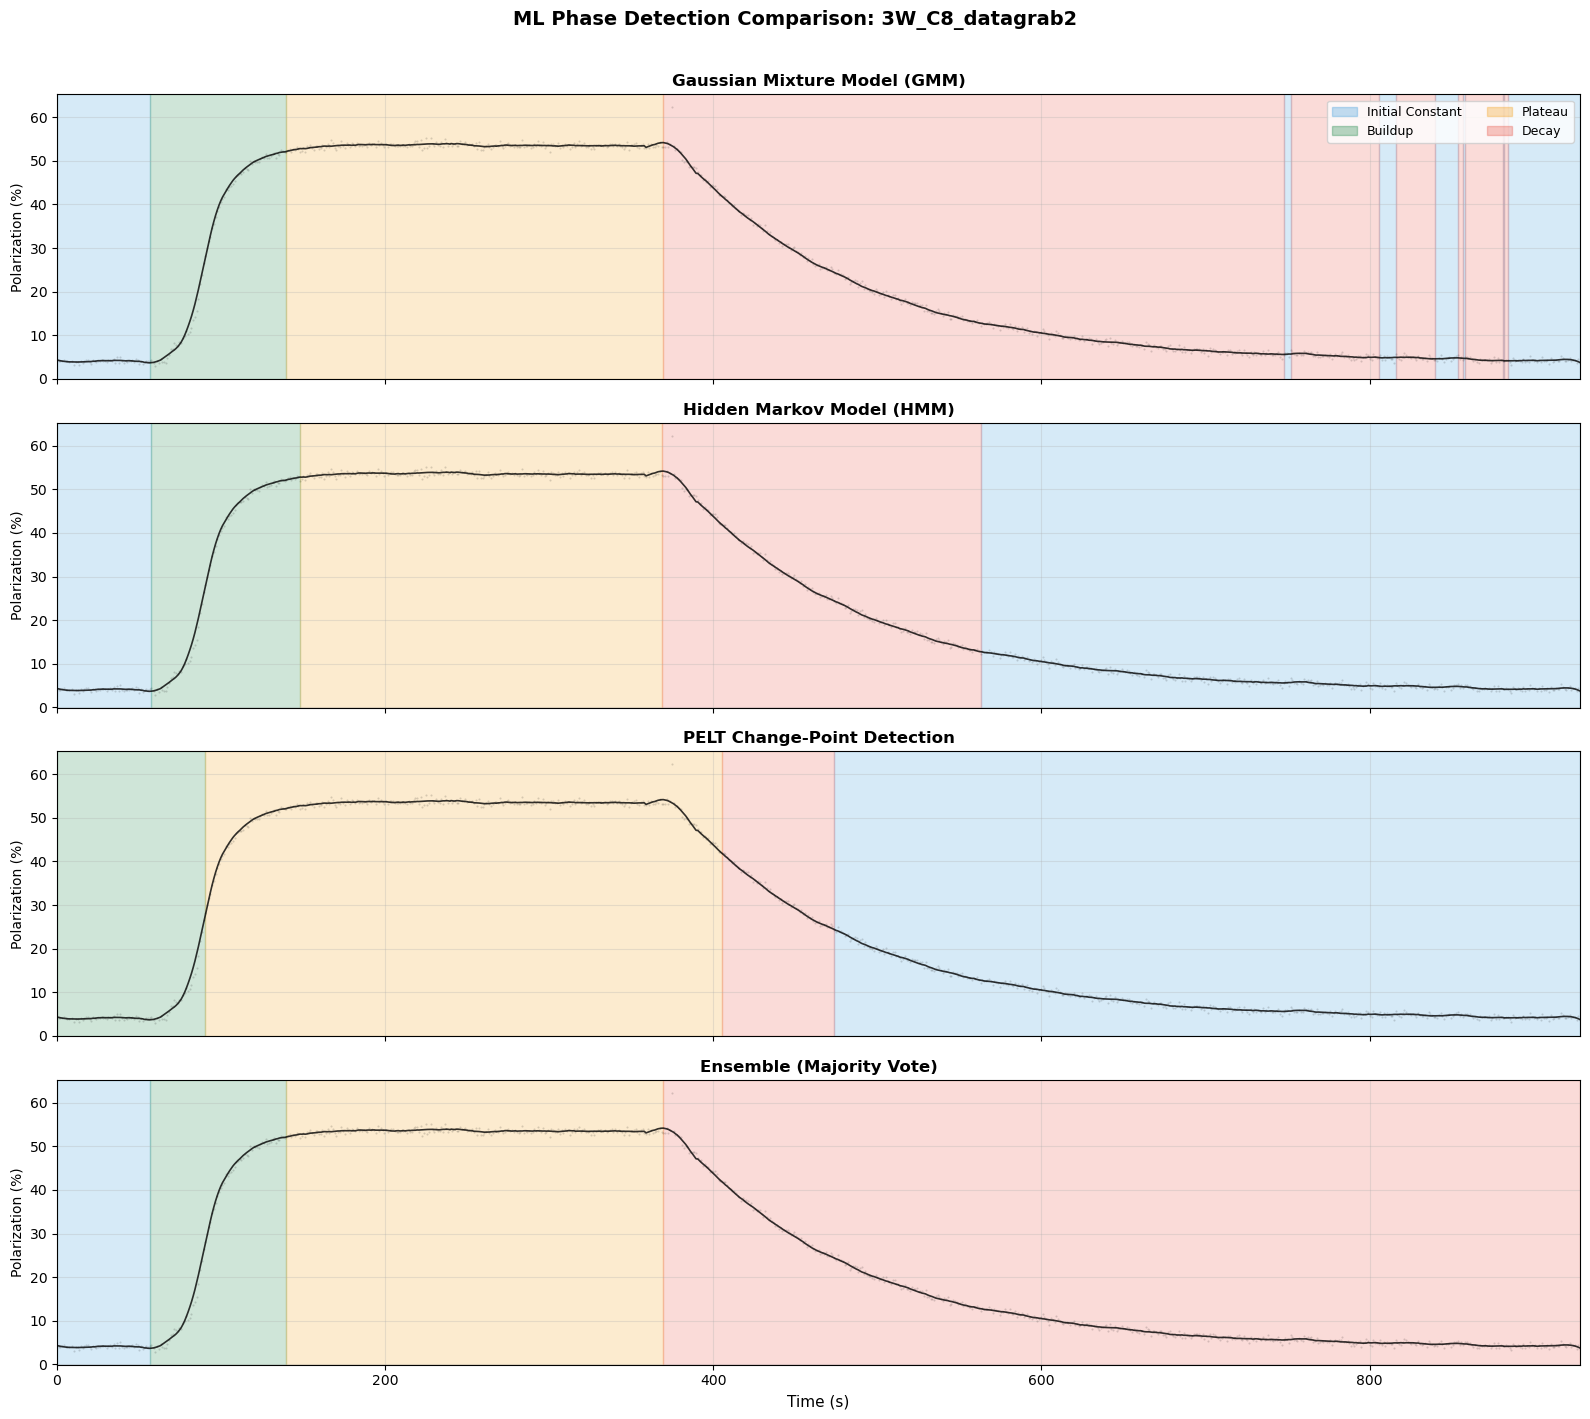

In [9]:
# ============================================================================
# Cell 8: Comprehensive Visualization
# ============================================================================

def plot_phase_comparison(df, methods_dict, filename, save_path=None):
    """
    Plot signal with phase coloring for multiple methods.
    
    methods_dict: {'Method Name': labels_array, ...}
    """
    time = df["time"].values
    pol = df["polarization"].values
    smooth = df["smoothed"].values
    
    n_methods = len(methods_dict)
    fig, axes = plt.subplots(n_methods, 1, figsize=(16, 3.5 * n_methods), sharex=True)
    if n_methods == 1:
        axes = [axes]
    
    phase_colors_list = ['#3498db', '#0f803e', '#f39c12', '#e74c3c']
    
    for ax, (method_name, labels) in zip(axes, methods_dict.items()):
        # Plot data
        ax.plot(time, pol, 'k.', alpha=0.15, markersize=1)
        ax.plot(time, smooth, 'k-', linewidth=1.2, alpha=0.8)
        
        # Color background by phase
        for phase_id in range(4):
            mask = labels == phase_id
            if np.any(mask):
                # Find contiguous runs
                changes = np.diff(mask.astype(int))
                starts = np.where(changes == 1)[0] + 1
                ends = np.where(changes == -1)[0] + 1
                
                if mask[0]:
                    starts = np.concatenate([[0], starts])
                if mask[-1]:
                    ends = np.concatenate([ends, [len(mask)]])
                
                for s, e in zip(starts, ends):
                    ax.axvspan(time[s], time[min(e, len(time)-1)], 
                              alpha=0.2, color=phase_colors_list[phase_id])
        
        ax.set_ylabel("Polarization (%)", fontsize=10)
        ax.set_title(f"{method_name}", fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(time[0], time[-1])
    
    axes[-1].set_xlabel("Time (s)", fontsize=11)
    
    # Legend
    patches = [mpatches.Patch(color=phase_colors_list[i], alpha=0.3, 
               label=phase_names[i]) for i in range(4)]
    axes[0].legend(handles=patches, loc='upper right', fontsize=9, ncol=2)
    
    fig.suptitle(f"ML Phase Detection Comparison: {filename}", fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# Plot all methods
plot_phase_comparison(df, {
    'Gaussian Mixture Model (GMM)': gmm_labels,
    'Hidden Markov Model (HMM)': hmm_labels,
    'PELT Change-Point Detection': pelt_labels,
    'Ensemble (Majority Vote)': ensemble_labels,
}, filename, save_path=os.path.join(OUTPUT_DIR, f"{filename}_ml_comparison.png"))

## 8. GMM Posterior Probabilities & Confidence

Visualize the soft assignment probabilities from the GMM. At each time point, the model gives a probability of belonging to each phase. Sharp transitions = high confidence; fuzzy transitions = boundary uncertainty.

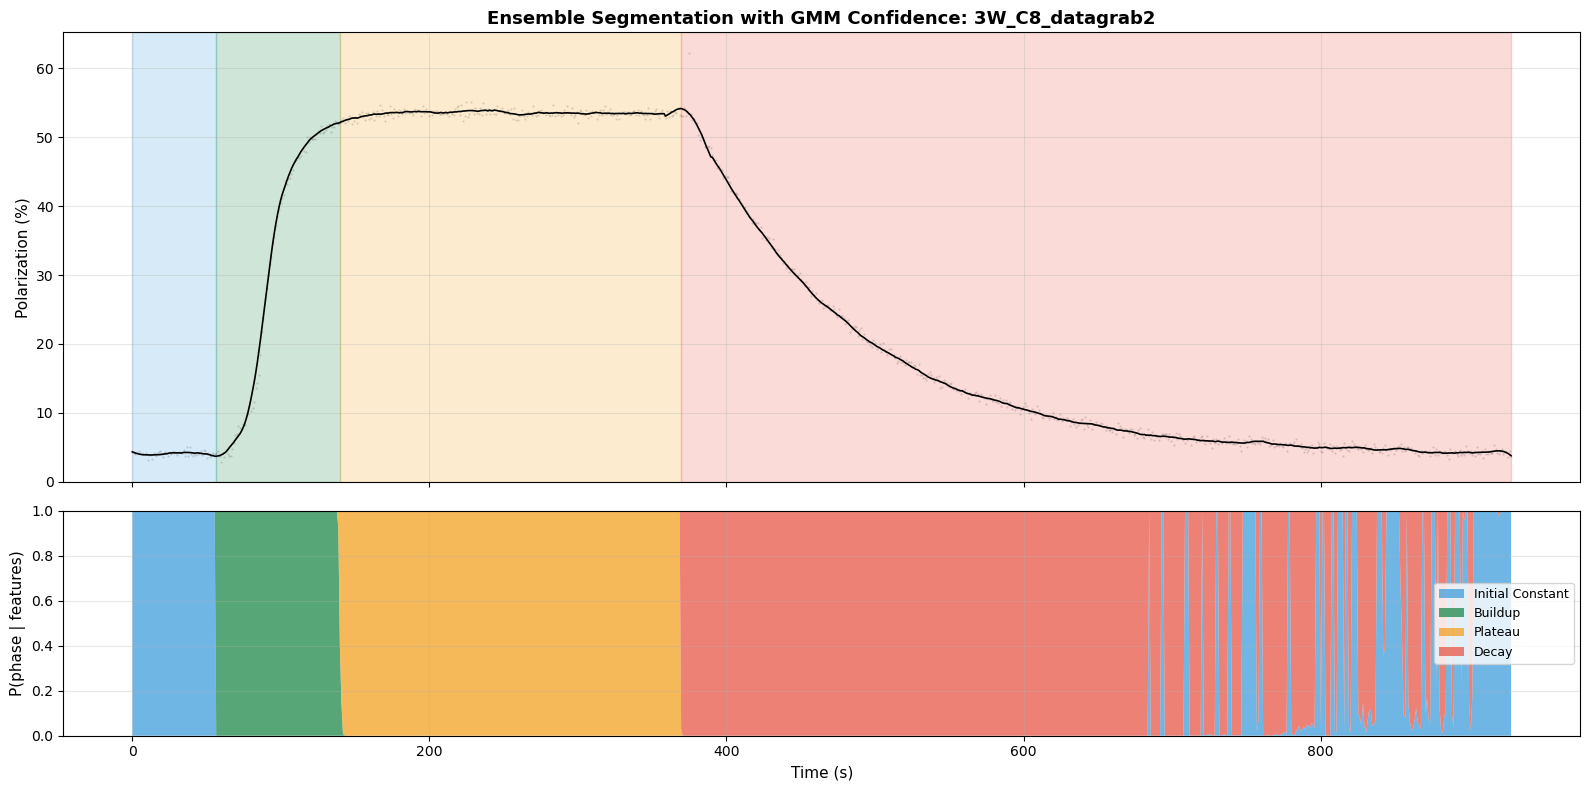

In [10]:
# ============================================================================
# Cell 9: GMM Posterior Probability Visualization
# ============================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

time = df["time"].values
phase_colors_list = ['#3498db', '#0f803e', '#f39c12', '#e74c3c']

# Top: Signal + phase coloring
ax1.plot(time, df["polarization"], 'k.', alpha=0.15, markersize=1)
ax1.plot(time, df["smoothed"], 'k-', linewidth=1.2)

for phase_id in range(4):
    mask = ensemble_labels == phase_id
    if np.any(mask):
        changes = np.diff(mask.astype(int))
        starts = np.where(changes == 1)[0] + 1
        ends = np.where(changes == -1)[0] + 1
        if mask[0]: starts = np.concatenate([[0], starts])
        if mask[-1]: ends = np.concatenate([ends, [len(mask)]])
        for s, e in zip(starts, ends):
            ax1.axvspan(time[s], time[min(e, len(time)-1)],
                       alpha=0.2, color=phase_colors_list[phase_id])

ax1.set_ylabel("Polarization (%)", fontsize=11)
ax1.set_title(f"Ensemble Segmentation with GMM Confidence: {filename}", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Bottom: Stacked posterior probabilities
# Reorder probabilities to match physical phase labels
# The GMM probs correspond to raw GMM components, need to map them
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
raw_probs = GaussianMixture(n_components=4, covariance_type='full', 
                             n_init=10, random_state=42).fit(X_scaled).predict_proba(X_scaled)

# Relabel probability columns to match physical phases
raw_labels_for_map = GaussianMixture(n_components=4, covariance_type='full', 
                                      n_init=10, random_state=42).fit(X_scaled).predict(X_scaled)
from scipy.ndimage import median_filter
smoothed_raw = median_filter(raw_labels_for_map, size=25)
mapped_labels = relabel_phases(smoothed_raw, df)

# Build probability mapping
label_map_reverse = {}
for raw_l, mapped_l in zip(smoothed_raw, mapped_labels):
    if raw_l not in label_map_reverse:
        label_map_reverse[raw_l] = mapped_l

# Reorder probs
reordered_probs = np.zeros_like(raw_probs)
for raw_col, phys_col in label_map_reverse.items():
    reordered_probs[:, phys_col] = raw_probs[:, raw_col]

ax2.stackplot(time, reordered_probs.T, 
              colors=phase_colors_list, alpha=0.7,
              labels=[phase_names[i] for i in range(4)])
ax2.set_ylabel("P(phase | features)", fontsize=11)
ax2.set_xlabel("Time (s)", fontsize=11)
ax2.set_ylim(0, 1)
ax2.legend(loc='center right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{filename}_gmm_confidence.png"), dpi=150, bbox_inches='tight')
plt.show()

## 9. Comparison: ML vs. Derivative-Based Method

Compare the ML ensemble ranges against the hand-tuned derivative-based `compute_fit_ranges()` from the main analysis notebook. This validates whether the ML approach can replace manual threshold tuning.

COMPARISON: ML Ensemble vs. Derivative-Based  |  3W_C8_datagrab2
Phase                              ML Range           Deriv Range    Δ_left   Δ_right
--------------------------------------------------------------------------------
Initial Constant       [    0.0,    55.4]  [    0.0,    54.4]     +0.0s     +1.0s
Buildup                [   56.5,   138.7]  [   64.4,   140.8]     -7.9s     -2.1s
Plateau                [  139.7,   368.4]  [  140.8,   370.5]     -1.1s     -2.1s
Decay                  [  369.5,   928.2]  [  370.5,   928.2]     -1.0s     +0.0s


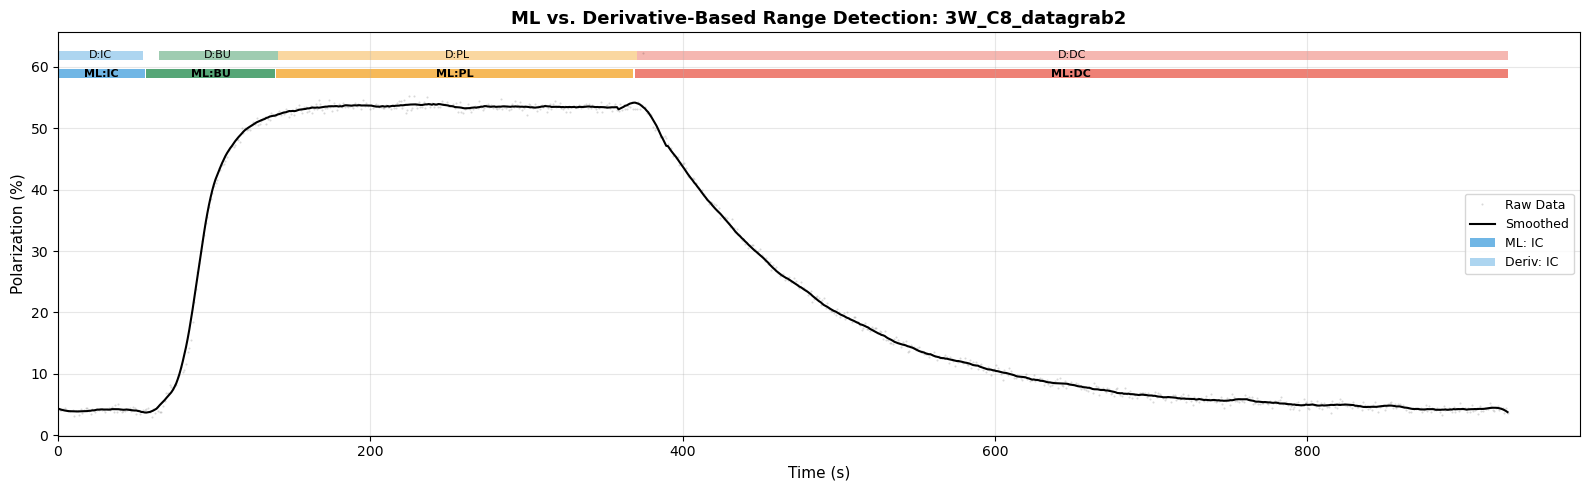

In [11]:
# ============================================================================
# Cell 10: Derivative-Based Method (from main notebook) for Comparison
# ============================================================================

def compute_fit_ranges_derivative(df):
    """
    Derivative-based phase detection (simplified from power_dependence_analysis.ipynb).
    Returns the same dict format as extract_ranges_from_labels().
    """
    time = df["time"].values
    pol_smooth = df["smoothed"].values
    deriv = df["derivative"].values
    t_min, t_max = time[0], time[-1]
    
    window = 15
    deriv_smooth = np.convolve(deriv, np.ones(window)/window, mode='same')
    deriv_max = np.max(deriv_smooth)
    deriv_min = np.min(deriv_smooth)
    pos_threshold = deriv_max * 0.15
    neg_threshold = deriv_min * 0.15
    zero_threshold = max(abs(deriv_max), abs(deriv_min)) * 0.05
    
    # Buildup start
    buildup_start_idx = 0
    consecutive_needed = 5
    for i in range(len(deriv_smooth) - consecutive_needed):
        if all(deriv_smooth[i:i+consecutive_needed] > pos_threshold):
            buildup_start_idx = i
            break
    
    # Plateau start
    deriv_peak_idx = np.argmax(deriv_smooth)
    plateau_start_idx = deriv_peak_idx
    for i in range(deriv_peak_idx, len(deriv_smooth) - consecutive_needed):
        if all(abs(deriv_smooth[i:i+consecutive_needed]) < zero_threshold):
            plateau_start_idx = i
            break
    
    # Decay start
    decay_start_idx = plateau_start_idx
    for i in range(plateau_start_idx, len(deriv_smooth) - consecutive_needed):
        if all(deriv_smooth[i:i+consecutive_needed] < neg_threshold):
            decay_start_idx = i
            break
    
    t_buildup_start = time[buildup_start_idx]
    t_plateau_start = time[plateau_start_idx]
    t_decay_start = time[decay_start_idx]
    
    # First rise detection
    first_rise_idx = buildup_start_idx
    for i in range(buildup_start_idx, 0, -1):
        if deriv_smooth[i] <= 0:
            first_rise_idx = i + 1
            break
    t_first_rise = time[first_rise_idx]
    
    # Flat start detection
    flat_start_idx = plateau_start_idx
    for i in range(deriv_peak_idx, len(deriv_smooth) - 8):
        if all(abs(deriv_smooth[i:i+8]) < zero_threshold):
            flat_start_idx = i
            break
    
    # Decay onset
    decay_onset_idx = decay_start_idx
    for i in range(decay_start_idx, plateau_start_idx, -1):
        if abs(deriv_smooth[i]) < zero_threshold:
            decay_onset_idx = i
            break
    
    return {
        'initial_constant_range_min': round(t_min, 1),
        'initial_constant_range_max': round(t_first_rise, 1),
        'buildup_range_min': round(t_first_rise + 10, 1),
        'buildup_range_max': round(time[flat_start_idx], 1),
        'constant_range_min': round(time[flat_start_idx], 1),
        'constant_range_max': round(time[decay_onset_idx], 1),
        'decay_range_min': round(t_decay_start, 1),
        'decay_range_max': round(t_max, 1),
    }


# Get derivative-based ranges
deriv_ranges = compute_fit_ranges_derivative(df)

# Comparison table
print(f"{'='*80}")
print(f"COMPARISON: ML Ensemble vs. Derivative-Based  |  {filename}")
print(f"{'='*80}")
print(f"{'Phase':<22s} {'ML Range':>20s}  {'Deriv Range':>20s}  {'Δ_left':>8s}  {'Δ_right':>8s}")
print(f"{'-'*80}")

phase_keys = [
    ("Initial Constant", 'initial_constant_range_min', 'initial_constant_range_max'),
    ("Buildup",          'buildup_range_min',          'buildup_range_max'),
    ("Plateau",          'constant_range_min',          'constant_range_max'),
    ("Decay",            'decay_range_min',             'decay_range_max'),
]

for name, k_min, k_max in phase_keys:
    ml_lo, ml_hi = ml_ranges[k_min], ml_ranges[k_max]
    dv_lo, dv_hi = deriv_ranges[k_min], deriv_ranges[k_max]
    d_lo = ml_lo - dv_lo
    d_hi = ml_hi - dv_hi
    print(f"{name:<22s} [{ml_lo:7.1f}, {ml_hi:7.1f}]  [{dv_lo:7.1f}, {dv_hi:7.1f}]  {d_lo:+7.1f}s  {d_hi:+7.1f}s")

print(f"{'='*80}")

# Visual comparison
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(time, df["polarization"], 'k.', alpha=0.15, markersize=1, label='Raw Data')
ax.plot(time, df["smoothed"], 'k-', linewidth=1.5, label='Smoothed')

colors = ['#3498db', '#0f803e', '#f39c12', '#e74c3c']
labels_list = ['IC', 'BU', 'PL', 'DC']

# ML ranges (solid bars at top)
y_top = df["smoothed"].max() * 1.05
for i, (_, k_min, k_max) in enumerate(phase_keys):
    lo, hi = ml_ranges[k_min], ml_ranges[k_max]
    ax.barh(y_top + 2, hi - lo, left=lo, height=1.5, color=colors[i], alpha=0.7,
            label=f'ML: {labels_list[i]}' if i == 0 else None)
    ax.text((lo + hi)/2, y_top + 2, f'ML:{labels_list[i]}', ha='center', va='center', fontsize=8, fontweight='bold')

# Derivative ranges (solid bars slightly below)
for i, (_, k_min, k_max) in enumerate(phase_keys):
    lo, hi = deriv_ranges[k_min], deriv_ranges[k_max]
    ax.barh(y_top + 5, hi - lo, left=lo, height=1.5, color=colors[i], alpha=0.4,
            label=f'Deriv: {labels_list[i]}' if i == 0 else None)
    ax.text((lo + hi)/2, y_top + 5, f'D:{labels_list[i]}', ha='center', va='center', fontsize=8)

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Polarization (%)", fontsize=11)
ax.set_title(f"ML vs. Derivative-Based Range Detection: {filename}", fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{filename}_ml_vs_deriv.png"), dpi=150, bbox_inches='tight')
plt.show()

## 10. Optimal Number of Phases — BIC/AIC Analysis

Is 4 really the optimal number of phases? Use information criteria to check. The BIC (Bayesian Information Criterion) penalizes model complexity — the minimum tells us the "right" number of clusters.

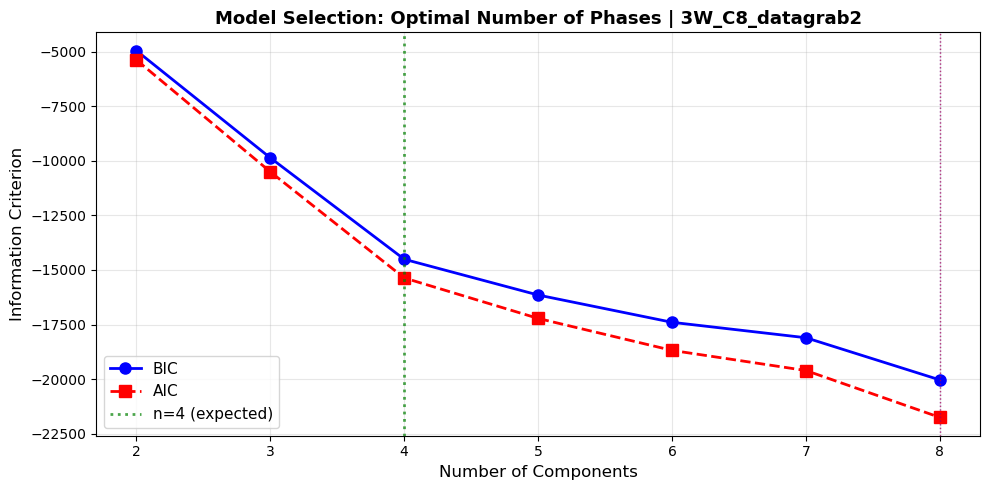

BIC minimum at n = 8 components
AIC minimum at n = 8 components
Physics expectation: n = 4 phases


In [12]:
# ============================================================================
# Cell 11: BIC/AIC Model Selection
# ============================================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

n_components_range = range(2, 9)
bics, aics = [], []

for n in n_components_range:
    gm = GaussianMixture(n_components=n, covariance_type='full', 
                          n_init=5, random_state=42)
    gm.fit(X_scaled)
    bics.append(gm.bic(X_scaled))
    aics.append(gm.aic(X_scaled))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(n_components_range), bics, 'bo-', linewidth=2, markersize=8, label='BIC')
ax.plot(list(n_components_range), aics, 'rs--', linewidth=2, markersize=8, label='AIC')
ax.axvline(x=4, color='green', linestyle=':', linewidth=2, alpha=0.7, label='n=4 (expected)')

# Mark the minimum
bic_min_n = list(n_components_range)[np.argmin(bics)]
aic_min_n = list(n_components_range)[np.argmin(aics)]
ax.axvline(x=bic_min_n, color='blue', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(x=aic_min_n, color='red', linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel("Number of Components", fontsize=12)
ax.set_ylabel("Information Criterion", fontsize=12)
ax.set_title(f"Model Selection: Optimal Number of Phases | {filename}", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(list(n_components_range))

plt.tight_layout()
plt.show()

print(f"BIC minimum at n = {bic_min_n} components")
print(f"AIC minimum at n = {aic_min_n} components")
print(f"Physics expectation: n = 4 phases")

## 11. Batch Processing: All 37 Files

Run the full ML pipeline on all Excel files. For each file:
1. Load & preprocess
2. Extract features
3. Run GMM, HMM, PELT
4. Ensemble → ranges
5. Compare with derivative-based ranges
6. Collect results into a summary DataFrame

In [13]:
# ============================================================================
# Cell 12: Batch Processing — All 37 Files
# ============================================================================

def process_single_file(file_path, save_plot=True):
    """
    Full ML pipeline for a single file.
    
    Returns:
        dict with filename, metadata, ML ranges, derivative ranges, agreement stats
    """
    fname = file_path.stem
    parts = fname.split("_")
    
    # Load & preprocess
    df_file = load_and_preprocess(file_path)
    
    # Feature extraction
    feats, _ = extract_features(df_file)
    
    # Run all three methods
    gmm_lab, gmm_prob, _ = gmm_phase_detection(df_file, feats)
    hmm_lab, _, _ = hmm_phase_detection(df_file, feats)
    pelt_lab, _, _ = pelt_phase_detection(df_file, feats)
    
    # Ensemble
    ens_lab = ensemble_phase_detection(gmm_lab, hmm_lab, pelt_lab, df_file)
    
    # Extract ML ranges
    ml_r = extract_ranges_from_labels(ens_lab, df_file)
    
    # Derivative-based ranges for comparison
    dv_r = compute_fit_ranges_derivative(df_file)
    
    # Agreement statistics
    agree_gmm_hmm = np.mean(gmm_lab == hmm_lab)
    agree_hmm_pelt = np.mean(hmm_lab == pelt_lab)
    agree_gmm_pelt = np.mean(gmm_lab == pelt_lab)
    agree_all = np.mean((gmm_lab == hmm_lab) & (hmm_lab == pelt_lab))
    
    # Build result row
    row = {
        'filename': fname,
        'power': parts[0] if len(parts) > 0 else '',
        'cell': parts[1] if len(parts) > 1 else '',
        'datagrab': parts[2] if len(parts) > 2 else '',
        # ML ranges
        'ml_ic_min': ml_r['initial_constant_range_min'],
        'ml_ic_max': ml_r['initial_constant_range_max'],
        'ml_bu_min': ml_r['buildup_range_min'],
        'ml_bu_max': ml_r['buildup_range_max'],
        'ml_pl_min': ml_r['constant_range_min'],
        'ml_pl_max': ml_r['constant_range_max'],
        'ml_dc_min': ml_r['decay_range_min'],
        'ml_dc_max': ml_r['decay_range_max'],
        # Derivative ranges
        'dv_ic_min': dv_r['initial_constant_range_min'],
        'dv_ic_max': dv_r['initial_constant_range_max'],
        'dv_bu_min': dv_r['buildup_range_min'],
        'dv_bu_max': dv_r['buildup_range_max'],
        'dv_pl_min': dv_r['constant_range_min'],
        'dv_pl_max': dv_r['constant_range_max'],
        'dv_dc_min': dv_r['decay_range_min'],
        'dv_dc_max': dv_r['decay_range_max'],
        # Agreement
        'agree_gmm_hmm': round(agree_gmm_hmm, 3),
        'agree_hmm_pelt': round(agree_hmm_pelt, 3),
        'agree_gmm_pelt': round(agree_gmm_pelt, 3),
        'agree_all_three': round(agree_all, 3),
    }
    
    # Boundary differences (ML - Deriv)
    for phase_abbr, k_min, k_max in [('ic', 'initial_constant_range_min', 'initial_constant_range_max'),
                                       ('bu', 'buildup_range_min', 'buildup_range_max'),
                                       ('pl', 'constant_range_min', 'constant_range_max'),
                                       ('dc', 'decay_range_min', 'decay_range_max')]:
        row[f'delta_{phase_abbr}_left'] = round(ml_r[k_min] - dv_r[k_min], 1)
        row[f'delta_{phase_abbr}_right'] = round(ml_r[k_max] - dv_r[k_max], 1)
    
    # Save plot
    if save_plot:
        plot_phase_comparison(df_file, {
            'GMM': gmm_lab, 'HMM': hmm_lab, 
            'PELT': pelt_lab, 'Ensemble': ens_lab,
        }, fname, save_path=os.path.join(OUTPUT_DIR, f"{fname}_ml_phases.png"))
        plt.close('all')
    
    return row


# ---- Run batch processing ----
print(f"Processing {len(excel_files)} files...\n")
batch_results = []
failed = []

for idx, fpath in enumerate(excel_files):
    print(f"[{idx+1:2d}/{len(excel_files)}] {fpath.stem}", end=" ... ")
    try:
        row = process_single_file(fpath, save_plot=False)  # Set True to save per-file plots
        batch_results.append(row)
        print(f"✓ Agreement: {row['agree_all_three']*100:.0f}%")
    except Exception as e:
        print(f"✗ FAILED: {e}")
        failed.append((fpath.stem, str(e)))

# Build results DataFrame
batch_df = pd.DataFrame(batch_results)

print(f"\n{'='*70}")
print(f"BATCH PROCESSING COMPLETE")
print(f"{'='*70}")
print(f"  Processed: {len(batch_results)} / {len(excel_files)} files")
print(f"  Failed:    {len(failed)} files")
if failed:
    for fn, err in failed:
        print(f"    ✗ {fn}: {err}")
print(f"  Mean 3-method agreement: {batch_df['agree_all_three'].mean()*100:.1f}%")

Processing 37 files...

[ 1/37] 3W_C8_datagrab1 ... ✓ Agreement: 15%
[ 2/37] 3W_C8_datagrab2 ... ✓ Agreement: 43%
[ 3/37] 3W_C8_datagrab3 ... ✓ Agreement: 43%
[ 4/37] 3W_C9_datagrab1 ... ✓ Agreement: 44%
[ 5/37] 3W_C9_datagrab2 ... ✓ Agreement: 35%
[ 6/37] 3W_C9_datagrab3 ... ✓ Agreement: 29%
[ 7/37] 3W_C9_datagrab4 ... ✓ Agreement: 54%
[ 8/37] 4W_C8_datagrab1 ... ✓ Agreement: 22%
[ 9/37] 4W_C8_datagrab2 ... ✓ Agreement: 26%
[10/37] 4W_C8_datagrab3 ... ✓ Agreement: 37%
[11/37] 4W_C9_datagrab1 ... ✓ Agreement: 29%
[12/37] 4W_C9_datagrab2 ... ✓ Agreement: 33%
[13/37] 4W_C9_datagrab3 ... ✓ Agreement: 51%
[14/37] 5W_C8_datagrab1 ... ✓ Agreement: 11%
[15/37] 5W_C8_datagrab2 ... ✓ Agreement: 28%
[16/37] 5W_C8_datagrab3 ... ✓ Agreement: 33%
[17/37] 5W_C9_datagrab1 ... ✓ Agreement: 45%
[18/37] 5W_C9_datagrab2 ... ✓ Agreement: 52%
[19/37] 5W_C9_datagrab3 ... ✓ Agreement: 58%
[20/37] 6W_C8_datagrab1 ... ✓ Agreement: 36%
[21/37] 6W_C8_datagrab2 ... ✓ Agreement: 31%
[22/37] 6W_C8_datagrab3 ... ✓ A

## 12. Batch Analysis: ML vs. Derivative Boundary Differences

Statistical comparison of ML and derivative-based boundaries across all 37 files. Shows distributions of boundary differences and identifies systematic biases.

Results saved to: /Users/snip/Documents/MEOP/ml_phase_plots/ml_phase_detection_results.csv

BOUNDARY DIFFERENCES: ML - Derivative (seconds)
Boundary                 Mean      Std   Median      Min      Max
--------------------------------------------------------------------------------
IC left                 +0.0s     0.0s    +0.0s    +0.0s    +0.0s
IC right                +6.3s    12.1s    +6.3s   -52.0s   +22.1s
BU left                 -0.6s     8.4s    -2.6s   -16.3s   +27.8s
BU right                -9.1s    15.5s    -9.5s   -37.8s   +19.9s
PL left                +57.8s   160.4s    +3.1s  -127.6s  +477.5s
PL right              +176.3s   230.7s    +3.1s    -5.3s  +606.4s
DC left                -90.8s   116.0s    -2.1s  -309.9s   +18.9s
DC right               -63.6s   122.4s    +0.0s  -395.5s    +0.0s


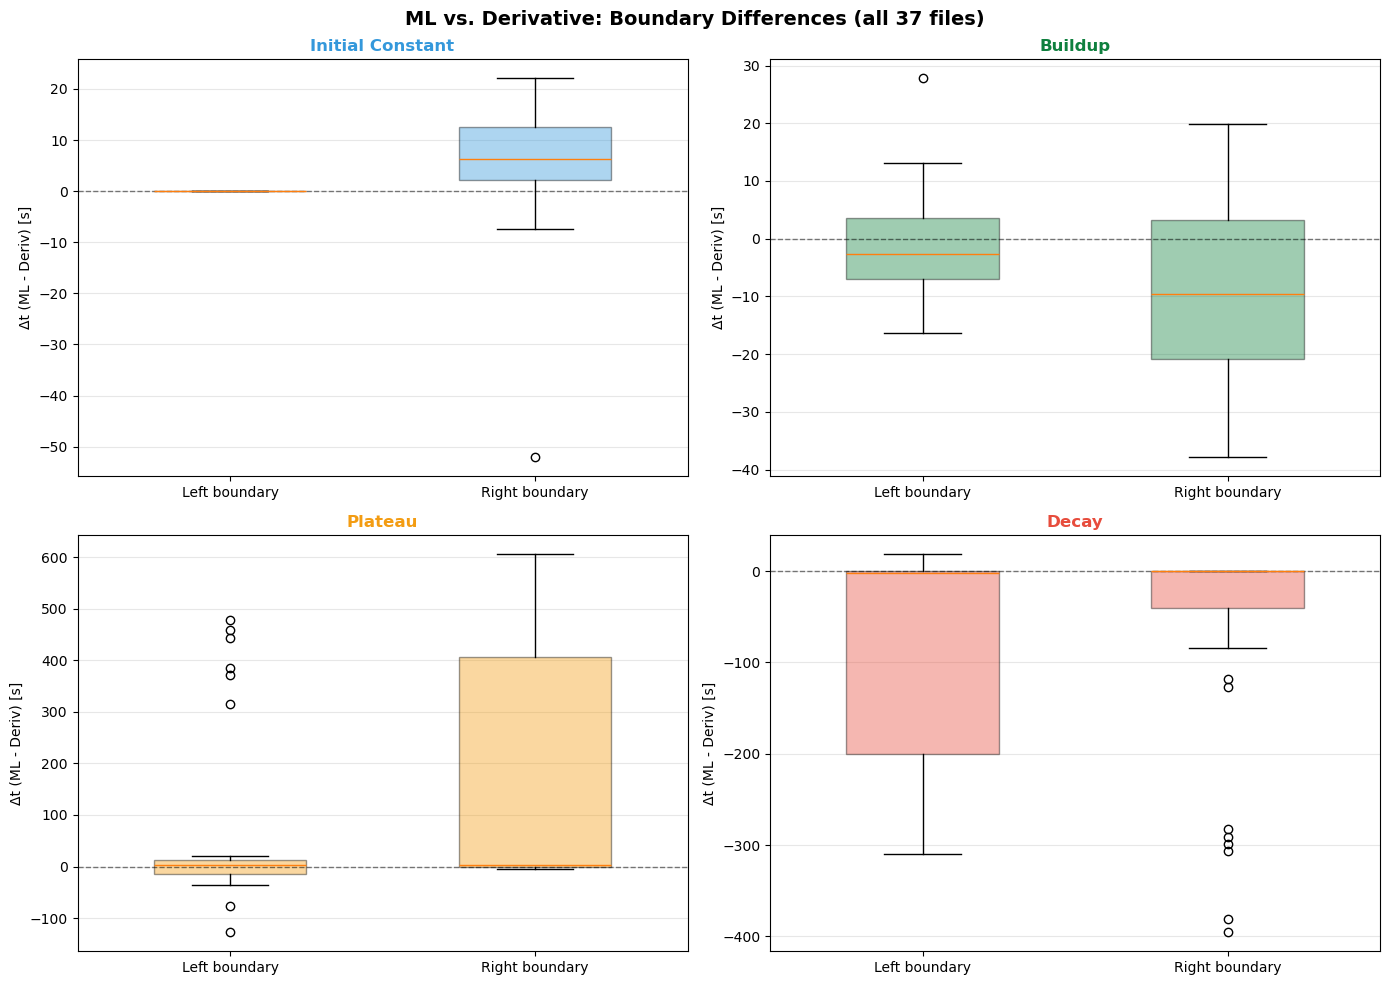

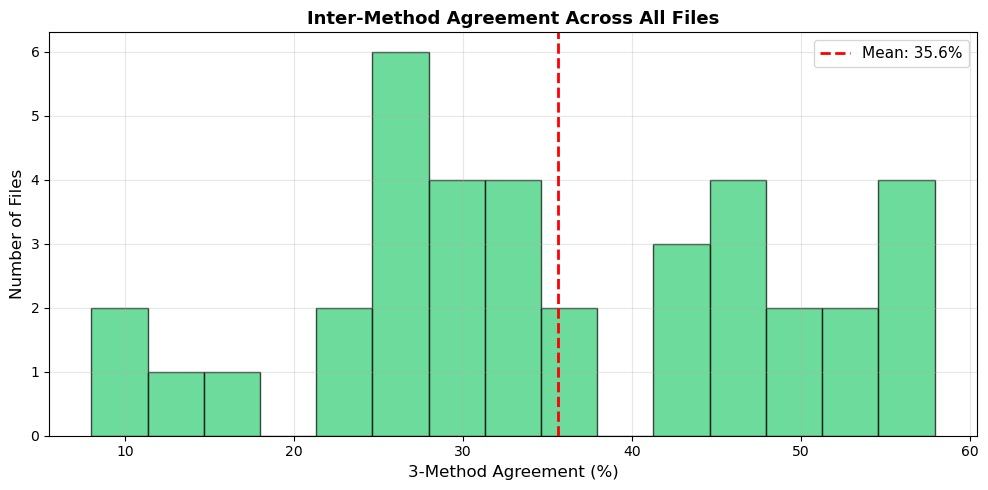

In [14]:
# ============================================================================
# Cell 13: Batch Summary Statistics & Visualization
# ============================================================================

# Save batch results to CSV
csv_path = os.path.join(OUTPUT_DIR, "ml_phase_detection_results.csv")
batch_df.to_csv(csv_path, index=False, float_format="%.1f")
print(f"Results saved to: {csv_path}\n")

# --- Summary statistics of boundary differences ---
delta_cols = ['delta_ic_left', 'delta_ic_right', 'delta_bu_left', 'delta_bu_right',
              'delta_pl_left', 'delta_pl_right', 'delta_dc_left', 'delta_dc_right']

print(f"{'='*80}")
print("BOUNDARY DIFFERENCES: ML - Derivative (seconds)")
print(f"{'='*80}")
print(f"{'Boundary':<20s} {'Mean':>8s} {'Std':>8s} {'Median':>8s} {'Min':>8s} {'Max':>8s}")
print(f"{'-'*80}")

for col in delta_cols:
    vals = batch_df[col].dropna()
    phase, side = col.replace('delta_', '').split('_')
    label = f"{phase.upper()} {side}"
    print(f"{label:<20s} {vals.mean():>+7.1f}s {vals.std():>7.1f}s {vals.median():>+7.1f}s {vals.min():>+7.1f}s {vals.max():>+7.1f}s")
print(f"{'='*80}")

# --- Visualization: Box plots of boundary differences ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("ML vs. Derivative: Boundary Differences (all 37 files)", fontsize=14, fontweight='bold')

phase_labels = ['IC', 'BU', 'PL', 'DC']
phase_full = ['Initial Constant', 'Buildup', 'Plateau', 'Decay']
colors = ['#3498db', '#0f803e', '#f39c12', '#e74c3c']

for idx, (phase_abbr, phase_name, color) in enumerate(zip(
    ['ic', 'bu', 'pl', 'dc'], phase_full, colors)):
    ax = axes[idx // 2, idx % 2]
    
    left_vals = batch_df[f'delta_{phase_abbr}_left'].dropna()
    right_vals = batch_df[f'delta_{phase_abbr}_right'].dropna()
    
    bp = ax.boxplot([left_vals, right_vals], labels=['Left boundary', 'Right boundary'],
                     patch_artist=True, widths=0.5)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.4)
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel("Δt (ML - Deriv) [s]", fontsize=10)
    ax.set_title(f"{phase_name}", fontsize=12, fontweight='bold', color=color)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ml_vs_deriv_boundary_boxplots.png"), dpi=150, bbox_inches='tight')
plt.show()

# --- Agreement histogram ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(batch_df['agree_all_three'] * 100, bins=15, color='#2ecc71', edgecolor='black', alpha=0.7)
ax.axvline(x=batch_df['agree_all_three'].mean() * 100, color='red', linewidth=2,
           linestyle='--', label=f"Mean: {batch_df['agree_all_three'].mean()*100:.1f}%")
ax.set_xlabel("3-Method Agreement (%)", fontsize=12)
ax.set_ylabel("Number of Files", fontsize=12)
ax.set_title("Inter-Method Agreement Across All Files", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "method_agreement_histogram.png"), dpi=150, bbox_inches='tight')
plt.show()

## 13. Export ML Ranges for ROOT Fitting

Export the ML-detected ranges in the same format as `compute_fit_ranges()` so they can be directly used in the main `power_dependence_analysis.ipynb` fitting pipeline.

In [15]:
# ============================================================================
# Cell 14: Export ML Ranges in Compatible Format
# ============================================================================

def ml_compute_fit_ranges(df, verbose=True):
    """
    Drop-in replacement for compute_fit_ranges() in power_dependence_analysis.ipynb.
    
    Uses the ML ensemble (GMM + HMM + PELT) instead of derivative thresholds.
    Returns the same dict format with the same keys.
    """
    feats, _ = extract_features(df)
    
    gmm_lab, _, _ = gmm_phase_detection(df, feats)
    hmm_lab, _, _ = hmm_phase_detection(df, feats)
    pelt_lab, _, _ = pelt_phase_detection(df, feats)
    
    ens_lab = ensemble_phase_detection(gmm_lab, hmm_lab, pelt_lab, df)
    ranges = extract_ranges_from_labels(ens_lab, df)
    
    if verbose:
        print(f"{'='*70}")
        print("ML-DETECTED FIT RANGES")
        print(f"{'='*70}")
        print(f"  1. Initial constant:  [{ranges['initial_constant_range_min']}, {ranges['initial_constant_range_max']}] s")
        print(f"  2. Buildup:           [{ranges['buildup_range_min']}, {ranges['buildup_range_max']}] s")
        print(f"  3. Plateau constant:  [{ranges['constant_range_min']}, {ranges['constant_range_max']}] s")
        print(f"  4. Decay:             [{ranges['decay_range_min']}, {ranges['decay_range_max']}] s")
        print(f"{'='*70}")
    
    return ranges

# Export ML ranges for all files
ml_ranges_export = []
for fpath in excel_files:
    fname = fpath.stem
    try:
        df_tmp = load_and_preprocess(fpath)
        r = ml_compute_fit_ranges(df_tmp, verbose=False)
        r['filename'] = fname
        ml_ranges_export.append(r)
    except Exception as e:
        print(f"  ✗ {fname}: {e}")

export_df = pd.DataFrame(ml_ranges_export)

# Reorder columns
col_order = ['filename', 
             'initial_constant_range_min', 'initial_constant_range_max',
             'buildup_range_min', 'buildup_range_max',
             'constant_range_min', 'constant_range_max', 
             'decay_range_min', 'decay_range_max']
export_df = export_df[[c for c in col_order if c in export_df.columns]]

export_csv = os.path.join(OUTPUT_DIR, "ml_fit_ranges_all_files.csv")
export_df.to_csv(export_csv, index=False, float_format="%.1f")

print(f"\nML ranges exported to: {export_csv}")
print(f"  {len(export_df)} files × {len(export_df.columns)} columns")
print(f"\nTo use in power_dependence_analysis.ipynb:")
print(f"  Replace compute_fit_ranges(df) with ml_compute_fit_ranges(df)")
print(f"\nSample output:")
export_df.head()


ML ranges exported to: /Users/snip/Documents/MEOP/ml_phase_plots/ml_fit_ranges_all_files.csv
  37 files × 9 columns

To use in power_dependence_analysis.ipynb:
  Replace compute_fit_ranges(df) with ml_compute_fit_ranges(df)

Sample output:


,filename,initial_constant_range_min,initial_constant_range_max,buildup_range_min,buildup_range_max,constant_range_min,constant_range_max,decay_range_min,decay_range_max
0,3W_C8_datagrab1,0.0,35.7,36.7,116.9,117.9,278.2,279.3,928.3
1,3W_C8_datagrab2,0.0,55.4,56.5,138.7,139.7,368.4,369.5,928.2
2,3W_C8_datagrab3,0.0,60.9,61.9,160.6,161.6,463.8,464.9,1004.8
3,3W_C9_datagrab1,0.0,54.6,55.7,172.2,173.2,357.1,358.2,812.2
4,3W_C9_datagrab2,0.0,50.2,51.3,200.0,201.1,403.3,404.3,821.4
